Integrantes do Grupo:
- Anselmo Faria Alvarez Júnior
- Augusto José Mangini dos Santos
- Julio Cesar da Silva

# Projeto 1: *support vector machines*

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitores: Jesus Paucar -- j236865@dac.unicamp.br

Este *notebook* faz parte da disciplina INF-0616 no curso de extensão MDC.  
Demais artefatos podem ser encontrados no moodle da disciplina:
[moodle.lab.ic.unicamp.br/709](https://moodle.ic.unicamp.br/moodle/course/view.php?id=709)

Instituto de Computação - Unicamp 2026

In [75]:
from __future__ import print_function

from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

from IPython.display import display

In [76]:
np.random.seed(1082141)
sns.set()

## Classificando imagens de dígitos
### Lendo o conjunto de dados

**Pen-Based Recognition of Handwritten Digits Data Set**
é um banco de imagens simples e bem conhecido em reconhecimento de imagens.  
Ele é composto por imagens em escala cinza de 8 por 8 pixels divididas em 10 classes de dígitos.

Uma descrição completa pode ser encontrada no seguinte link: [archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits](http://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits)

In [77]:
x, y = datasets.load_digits(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=.5,
                                                    random_state=183212)
print('amostras em treino: %i' % x_train.shape[0],
      'amostras em teste: %i' % x_test.shape[0],
      'número de características: %i' % x_train.shape[1],
      'número de classes: %i' % (np.max(y_train) + 1),
      sep='\n', end='\n\n')

amostras em treino: 898
amostras em teste: 899
número de características: 64
número de classes: 10



### 64 primeiras amostras no conjunto de treinamento

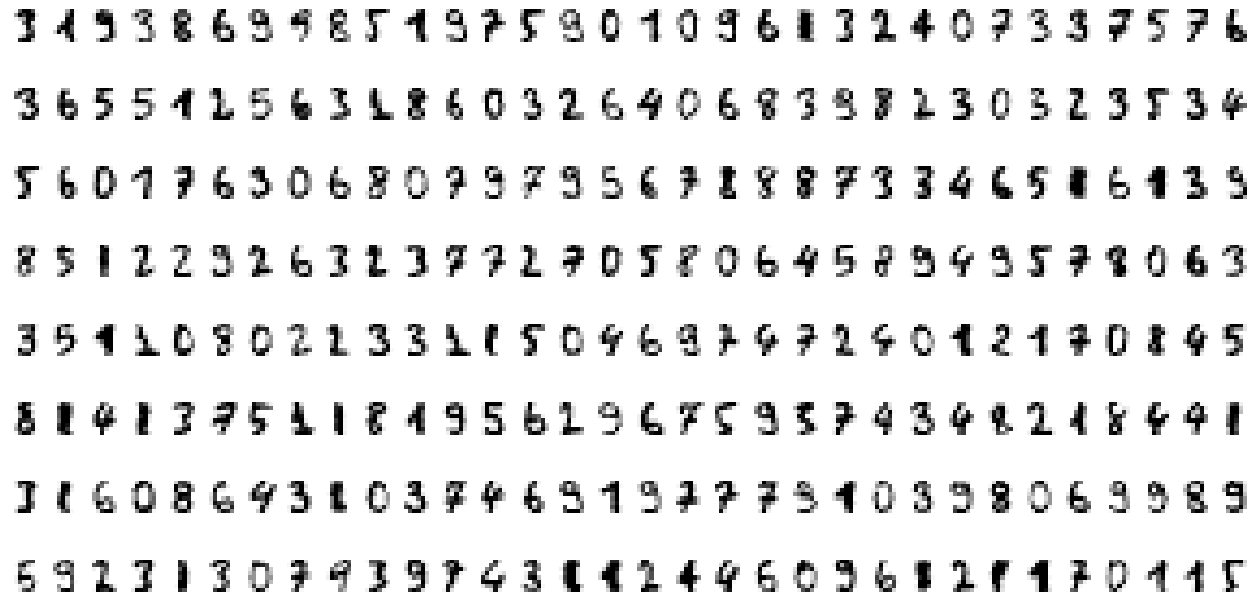

In [78]:
plt.figure(figsize=(16, 8))

for ix in range(8  * 32):
    plt.subplot(8, 32, ix + 1)
    plt.imshow(x_train[ix].reshape(8, 8), cmap='Greys')
    plt.axis('off')

### Visualizando o conjunto e frequências das classes

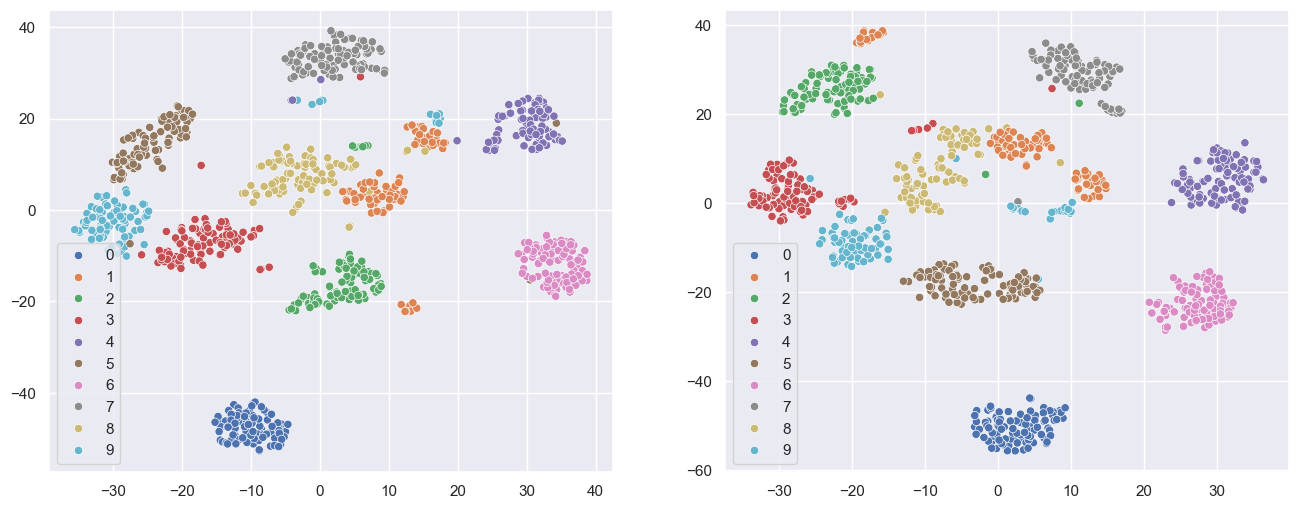

In [79]:
from sklearn.manifold import TSNE

encoder2D = TSNE()
w_train = encoder2D.fit_transform(x_train)
w_test = encoder2D.fit_transform(x_test)

plt.figure(figsize=(16, 6))
categorical_colors = sns.color_palette()

for ix, (x, y) in enumerate(((w_train, y_train), (w_test, y_test))):
    plt.subplot(1, 2, ix + 1)
    sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, palette=categorical_colors);

<Axes: title={'center': 'Frequencia das classes no conjunto de teste (899 amostras)'}>

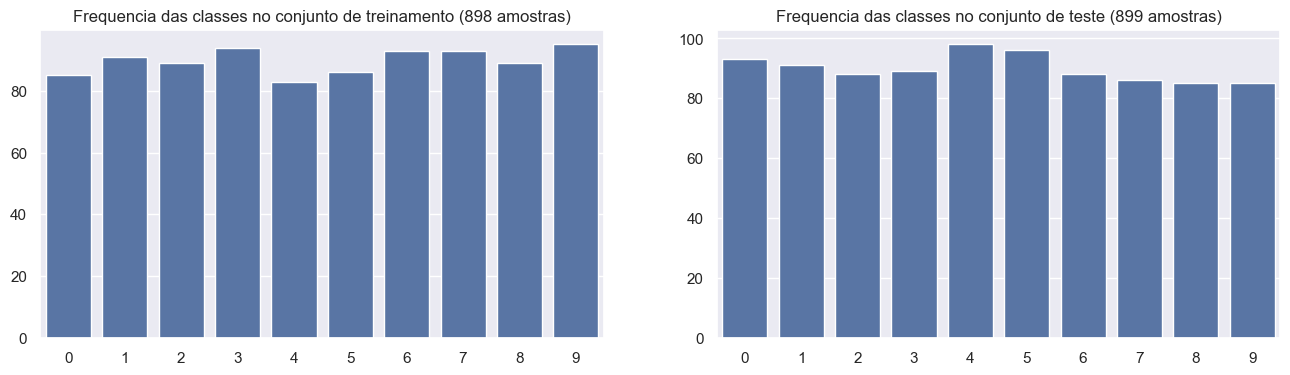

In [80]:
plt.figure(figsize=(16, 4))

plt.subplot(121)
plt.title('Frequencia das classes no conjunto de treinamento (%i amostras)' % len(x_train))
labels, counts = np.unique(y_train, return_counts=True)
sns.barplot(x=labels, y=counts)

plt.subplot(122)
plt.title('Frequencia das classes no conjunto de teste (%i amostras)' % len(x_test))
labels, counts = np.unique(y_test, return_counts=True)
sns.barplot(x=labels, y=counts)

### Modelando um classificador de digitos

**Atividade (3 pts):** defina e treine uma máquina de vetor de suporte com diferentes tipos de kernel, utilizando o scikit-learn. Avalie os diversos tipos de kernel e seus respectivos parâmetros com relação a qualidade da solução. Você deve separar uma parte do conjunto de treino para fazer a validação cruzada. Não utilize o conjunto de teste ainda.

Conjunto de treino: x_train  
Conjunto de teste: x_test  

### Criando o conjunto de validação cruzada usando K-fold

In [81]:
modelo = SVC()
scores = cross_val_score(modelo, x_train, y_train, cv=5)  # 5 folds
print(scores.mean())

0.9799689633767846


#### Explorando o kernel linear (variação de C com validação cruzada)

Testando SVM com **kernel linear** variando o parâmetro `C`. Para cada valor de `C`, validação cruzada (K-fold) apenas no conjunto de treino (`x_train`, `y_train`) para estimar a qualidade do modelo.

C = 0.0001   treino = 0.9521   CV (5-fold) = 0.9432 (+/- 0.0167)
C = 0.001    treino = 0.9889   CV (5-fold) = 0.9766 (+/- 0.0081)
C = 0.01     treino = 1.0000   CV (5-fold) = 0.9722 (+/- 0.0116)
C = 0.1      treino = 1.0000   CV (5-fold) = 0.9722 (+/- 0.0116)
C = 1        treino = 1.0000   CV (5-fold) = 0.9722 (+/- 0.0116)
C = 10       treino = 1.0000   CV (5-fold) = 0.9722 (+/- 0.0116)
C = 100      treino = 1.0000   CV (5-fold) = 0.9722 (+/- 0.0116)


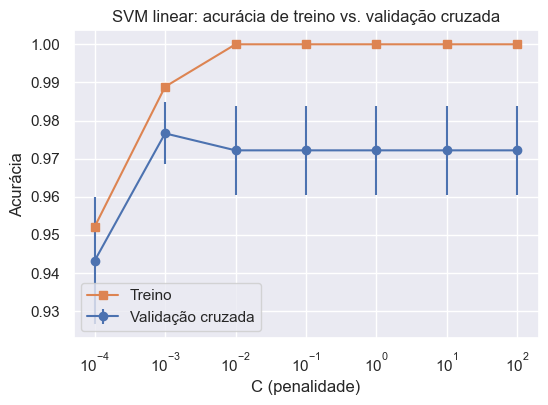


Melhor C pela validação cruzada: 0.001 (acurácia CV = 0.9766)


In [82]:
def linear_svm_cv(x_train, y_train, penaltyArray=[1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0], cv=5):
    train_accs = []
    cv_means = []
    cv_stds = []

    for penalty in penaltyArray:
        clf = SVC(kernel='linear', C=penalty)

        # validação cruzada: cross_val_score clona e re-treina o modelo em cada fold
        scores = cross_val_score(clf, x_train, y_train, cv=cv)
        cv_means.append(scores.mean())
        cv_stds.append(scores.std())

        # acurácia no treino completo (apenas para referência/comparação)
        clf.fit(x_train, y_train)
        train_accs.append(accuracy_score(y_train, clf.predict(x_train)))

        print('C = %-8g treino = %.4f   CV (%d-fold) = %.4f (+/- %.4f)'
              % (penalty, train_accs[-1], cv, cv_means[-1], cv_stds[-1]))

    plt.figure(figsize=(6, 4))
    plt.errorbar(penaltyArray, cv_means, yerr=cv_stds, marker='o', label='Validação cruzada')
    plt.plot(penaltyArray, train_accs, marker='s', label='Treino')
    plt.xscale('log')
    plt.xlabel('C (penalidade)')
    plt.ylabel('Acurácia')
    plt.title('SVM linear: acurácia de treino vs. validação cruzada')
    plt.legend()
    plt.grid(True)
    plt.show()

    best_idx = int(np.argmax(cv_means))
    print('\nMelhor C pela validação cruzada: %g (acurácia CV = %.4f)'
          % (penaltyArray[best_idx], cv_means[best_idx]))
    return penaltyArray[best_idx]


best_C_linear = linear_svm_cv(x_train, y_train)

No treino anterior, no conjunto de treino para valores de C acima de 0.001 é possível notar que houve overfitting do modelo

#### Explorando o kernel RBF (variando C e gamma com validação cruzada)

No kernel `linear` o parâmetro `gamma` não tem efeito (o kernel linear é apenas `K(x, x') = x . x'`). No kernel **RBF**, `gamma` controla o alcance de influência de cada amostra. Por isso, aqui variando `C` **e** `gamma` juntos, novamente usando validação cruzada.

C = 0.1      gamma = 0.0001   CV (5-fold) = 0.6949
C = 0.1      gamma = 0.001    CV (5-fold) = 0.9365
C = 0.1      gamma = 0.01     CV (5-fold) = 0.1237
C = 0.1      gamma = 0.1      CV (5-fold) = 0.1069
C = 1        gamma = 0.0001   CV (5-fold) = 0.9610
C = 1        gamma = 0.001    CV (5-fold) = 0.9878
C = 1        gamma = 0.01     CV (5-fold) = 0.6704
C = 1        gamma = 0.1      CV (5-fold) = 0.1091
C = 10       gamma = 0.0001   CV (5-fold) = 0.9822
C = 10       gamma = 0.001    CV (5-fold) = 0.9878
C = 10       gamma = 0.01     CV (5-fold) = 0.7004
C = 10       gamma = 0.1      CV (5-fold) = 0.1091
C = 100      gamma = 0.0001   CV (5-fold) = 0.9777
C = 100      gamma = 0.001    CV (5-fold) = 0.9878
C = 100      gamma = 0.01     CV (5-fold) = 0.7004
C = 100      gamma = 0.1      CV (5-fold) = 0.1091


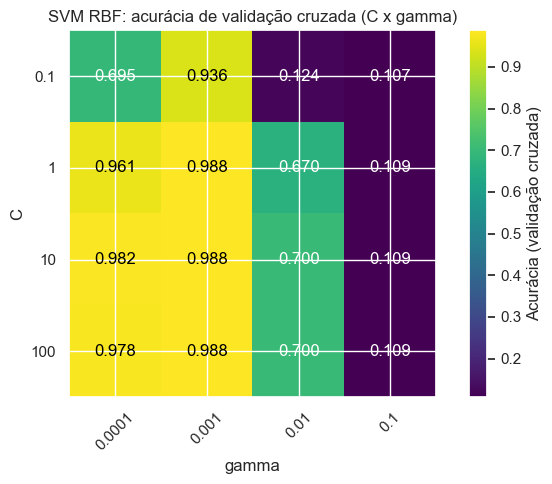


Melhor combinação pela validação cruzada: C=1, gamma=0.001 (acurácia CV = 0.9878)


In [83]:
def rbf_svm_cv(x_train, y_train, penaltyArray=[1e-1, 1.0, 10.0, 100.0], gammaArray=[1e-4, 1e-3, 1e-2, 1e-1], cv=5):
    cv_means = np.zeros((len(penaltyArray), len(gammaArray)))

    for i, penalty in enumerate(penaltyArray):
        for j, gamma in enumerate(gammaArray):
            clf = SVC(kernel='rbf', C=penalty, gamma=gamma)
            scores = cross_val_score(clf, x_train, y_train, cv=cv)
            cv_means[i, j] = scores.mean()
            print('C = %-8g gamma = %-8g CV (%d-fold) = %.4f' % (penalty, gamma, cv, cv_means[i, j]))

    plt.figure(figsize=(7, 5))
    plt.imshow(cv_means, interpolation='nearest', cmap=plt.cm.viridis)
    plt.xlabel('gamma')
    plt.ylabel('C')
    plt.colorbar(label='Acurácia (validação cruzada)')
    plt.xticks(np.arange(len(gammaArray)), ['%g' % g for g in gammaArray], rotation=45)
    plt.yticks(np.arange(len(penaltyArray)), ['%g' % c for c in penaltyArray])
    plt.title('SVM RBF: acurácia de validação cruzada (C x gamma)')

    # anota os valores de acurácia em cada célula do heatmap
    for i in range(len(penaltyArray)):
        for j in range(len(gammaArray)):
            plt.text(j, i, '%.3f' % cv_means[i, j], ha='center', va='center',
                     color='white' if cv_means[i, j] < cv_means.max() * 0.85 else 'black')

    plt.tight_layout()
    plt.show()

    best_i, best_j = np.unravel_index(np.argmax(cv_means), cv_means.shape)
    best_C, best_gamma = penaltyArray[best_i], gammaArray[best_j]
    print('\nMelhor combinação pela validação cruzada: C=%g, gamma=%g (acurácia CV = %.4f)'
          % (best_C, best_gamma, cv_means[best_i, best_j]))
    return best_C, best_gamma


best_C_rbf, best_gamma_rbf = rbf_svm_cv(x_train, y_train)

É possível observar que para valores de gamma acima de 0.001 o modelo entra em underfitting severo

### Avaliando o modelo treinado

**Atividade (2 pts):** avalie o seu melhor modelo treinado no item anterior sobre o conjunto de teste previamente separado. Reporte a acurácia média, a matriz de confusão e outras métricas que achar válido.

Melhor modelo encontrado - kernel RBF com C=1 e gamma = 0,001

In [84]:
melhor_modelo = SVC(kernel='rbf', C=1, gamma=0.001)
melhor_modelo.fit(x_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [85]:
y_pred = melhor_modelo.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print('Acurácia no teste: %.4f' % acc)

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusão:')
print(cm)

print(classification_report(y_test, y_pred))

Acurácia no teste: 0.9867
Matriz de confusão:
[[92  0  0  0  1  0  0  0  0  0]
 [ 0 91  0  0  0  0  0  0  0  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  1 88  0  0  0  0  0  0]
 [ 0  1  0  0 97  0  0  0  0  0]
 [ 0  0  0  0  0 96  0  0  0  0]
 [ 0  0  0  0  0  1 86  0  1  0]
 [ 0  0  0  0  0  0  0 84  0  2]
 [ 0  2  0  0  0  0  0  0 83  0]
 [ 0  0  0  1  0  1  0  0  1 82]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        93
           1       0.97      1.00      0.98        91
           2       0.99      1.00      0.99        88
           3       0.99      0.99      0.99        89
           4       0.99      0.99      0.99        98
           5       0.98      1.00      0.99        96
           6       1.00      0.98      0.99        88
           7       1.00      0.98      0.99        86
           8       0.98      0.98      0.98        85
           9       0.98      0.96      0.97        85

    accuracy               

**Atividade (4 pts):** treine dois ou mais classificadores (Random forest, logistic regression, etc.) e reporte o suas respectivas métricas sobre as porções de validação separadas (acurácia, acurácia balanceada, precision, etc). Compare seus melhores classificadores com os resultados da SVM no conjunto de teste.



In [86]:
modelos = {
    'Random Forest': RandomForestClassifier(random_state=1082141),
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=1082141),
}

metricas = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# validação cruzada (5-fold) usando somente x_train/y_train, sem tocar no teste
resultados_cv = {}
for nome, modelo in modelos.items():
    scores = cross_validate(modelo, x_train, y_train, cv=5, scoring=metricas)
    resultados_cv[nome] = scores

    print('--- %s (validação cruzada, 5-fold) ---' % nome)
    for m in metricas:
        media = scores['test_' + m].mean()
        desvio = scores['test_' + m].std()
        print('%-18s: %.4f (+/- %.4f)' % (m, media, desvio))
    print()

--- Random Forest (validação cruzada, 5-fold) ---
accuracy          : 0.9610 (+/- 0.0199)
balanced_accuracy : 0.9611 (+/- 0.0203)
precision_macro   : 0.9626 (+/- 0.0193)
recall_macro      : 0.9611 (+/- 0.0203)
f1_macro          : 0.9610 (+/- 0.0204)

--- Logistic Regression (validação cruzada, 5-fold) ---
accuracy          : 0.9543 (+/- 0.0163)
balanced_accuracy : 0.9540 (+/- 0.0166)
precision_macro   : 0.9575 (+/- 0.0152)
recall_macro      : 0.9540 (+/- 0.0166)
f1_macro          : 0.9536 (+/- 0.0173)



#### Comparando os melhores classificadores com a SVM no conjunto de teste

In [87]:
print('=== Comparação final no conjunto de teste ===')
bal_acc_svm = balanced_accuracy_score(y_test, y_pred)
print('SVM (RBF, C=1, gamma=0.001): acurácia = %.4f, acurácia balanceada = %.4f' % (acc, bal_acc_svm))

for nome, modelo in modelos.items():
    modelo.fit(x_train, y_train)
    y_pred_modelo = modelo.predict(x_test)

    acc_teste = accuracy_score(y_test, y_pred_modelo)
    bal_acc_teste = balanced_accuracy_score(y_test, y_pred_modelo)

    print('%s: acurácia = %.4f, acurácia balanceada = %.4f' % (nome, acc_teste, bal_acc_teste))

=== Comparação final no conjunto de teste ===
SVM (RBF, C=1, gamma=0.001): acurácia = 0.9867, acurácia balanceada = 0.9863
Random Forest: acurácia = 0.9722, acurácia balanceada = 0.9713
Logistic Regression: acurácia = 0.9499, acurácia balanceada = 0.9496


**Pergunta (1pt):** qual classificador apresentou os melhores resultados? Qual critério você utilizou para definir sua escolha? Discuta.

O classificador que apresentou o melhor resultado foi o SVM com Kernel RBF, otimizado com os parâmetros C=1 e gamma = 0,001. Os critérios utilizados para escolha foram a acurácia/acurácia balanceada no conjunto de teste, e com essa configuração o RBF conseguiu resultados de acurácia de 0,9867 e acurácia balanceada de 0,9863. Em comparação, os modelos de Random Forest (RF) e Logistic Regression (LR) tiveram acurácia de 0,9722 e 0,9499, e acurácia balanceada de 0,9713 e 0,9496 respectivamente.  

Vale ressaltar que os modelos de RF e LR não foram otimizadas com grid search iguam o SVM, portanto isso não é uma comparação 100% justa. Como a diferença de precisão entre os modelos de RF e SVM foram mínimos, pode ser que a otimização do RF deixasse esse melhor que o SVM, porém como ambos os resultados são muito altos (98% e 97% de acurácia), provavelmente essa diferença é irrelevante.

Uma hipótese do porquê o modelo de SVM com RBF é superior aos outros é de que esse modelo é não-linear e consegue capturar padrões mais complexos de pixels do que modelos lineares, que é o caso do RBF com kernel linear e do LR padrão. Isso sugere que a fronteira de decisão entre os dígitos não é linearmente bem separável nesse espaço.